**[Heart](https://www.kaggle.com/fedesoriano/heart-failure-prediction):
Heart Failure Prediction Dataset
11 clinical features for predicting heart disease events.**

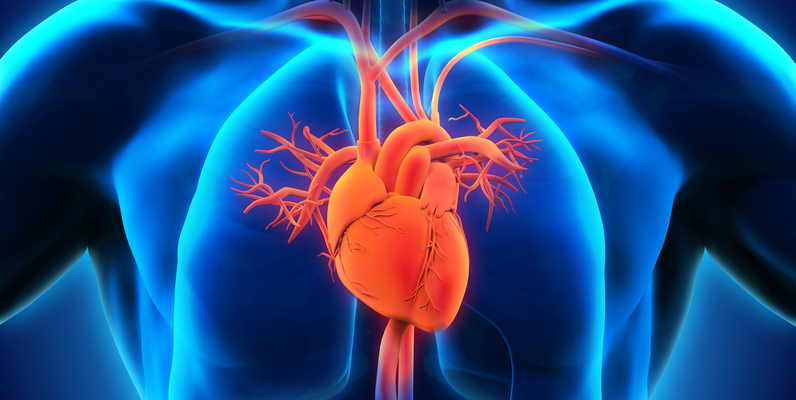

In [384]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from matplotlib.ticker import FuncFormatter

%matplotlib inline
np.random.seed(1)
warnings.filterwarnings('ignore', 'Maximum number of iteration reached before convergence.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Liblinear failed to converge, increase the number of iterations.*') #Sem isso aqui ele fica falando pra aumentar o max_iter
warnings.filterwarnings('ignore', 'Warm-start fitting without increasing n_estimators does not fit new trees.*') #Sem isso aqui ele fica falando pra aumentar o max_iter

**Processo de download automático dos dados**

In [216]:
!gdown --id '1gWoTx4NjmecMVQmjyEliDcCLzRhKg8If'

Downloading...
From: https://drive.google.com/uc?id=1gWoTx4NjmecMVQmjyEliDcCLzRhKg8If
To: /content/heart.csv
100% 35.9k/35.9k [00:00<00:00, 59.2MB/s]


**Tratamento de dados**

Age: idade [years]

Sex: sexo [M: Male, F: Female]

ChestPainType: tipo de dor no peito [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

RestingBP: pressão arterial em repouso [mm Hg]

Cholesterol: colesterol sérico [mm/dl]

FastingBS: açúcar no sangue em jejum [1: if FastingBS > 120 mg/dl, 0: otherwise]

RestingECG: resultados do eletrocardiograma de repouso [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

MaxHR: freqüência cardíaca máxima alcançada [Numeric value between 60 and 202]

ExerciseAngina: angina induzida pelo exercício [Y: Yes, N: No]

Oldpeak: oldpeak = ST [Numeric value measured in depression]

ST_Slope: inclinação do segmento ST de pico do exercício [Up: upsloping, Flat: flat, Down: downsloping]

HeartDisease: saida [1: heart disease, 0: Normal]


In [217]:
df_heart = pd.read_csv('heart.csv')

In [218]:
df_heart

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [219]:
df_heart.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [220]:
df_heart.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [221]:
df_heart['Sex'].unique()

array(['M', 'F'], dtype=object)

In [222]:
df_heart['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [223]:
df_heart['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [224]:
df_heart['ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

In [225]:
df_heart['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [226]:
df_heart = pd.get_dummies(df_heart,columns=['Sex'], drop_first=False)

In [227]:
df_heart = pd.get_dummies(df_heart,columns=['ChestPainType'], drop_first=False)

In [228]:
df_heart = pd.get_dummies(df_heart,columns=['RestingECG'], drop_first=False)

In [229]:
df_heart = pd.get_dummies(df_heart,columns=['ExerciseAngina'], drop_first=False)

In [230]:
df_heart = pd.get_dummies(df_heart,columns=['ST_Slope'], drop_first=False)

In [231]:
df_heart

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,0,1,0,0,0,1,0,1,0,1,0,0,1,0
914,68,144,193,1,141,3.4,1,0,1,1,0,0,0,0,1,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,0,1,1,0,0,0,0,1,0,0,1,0,1,0
916,57,130,236,0,174,0.0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0


In [232]:
df_heart.dtypes

Age                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
Oldpeak              float64
HeartDisease           int64
Sex_F                  uint8
Sex_M                  uint8
ChestPainType_ASY      uint8
ChestPainType_ATA      uint8
ChestPainType_NAP      uint8
ChestPainType_TA       uint8
RestingECG_LVH         uint8
RestingECG_Normal      uint8
RestingECG_ST          uint8
ExerciseAngina_N       uint8
ExerciseAngina_Y       uint8
ST_Slope_Down          uint8
ST_Slope_Flat          uint8
ST_Slope_Up            uint8
dtype: object

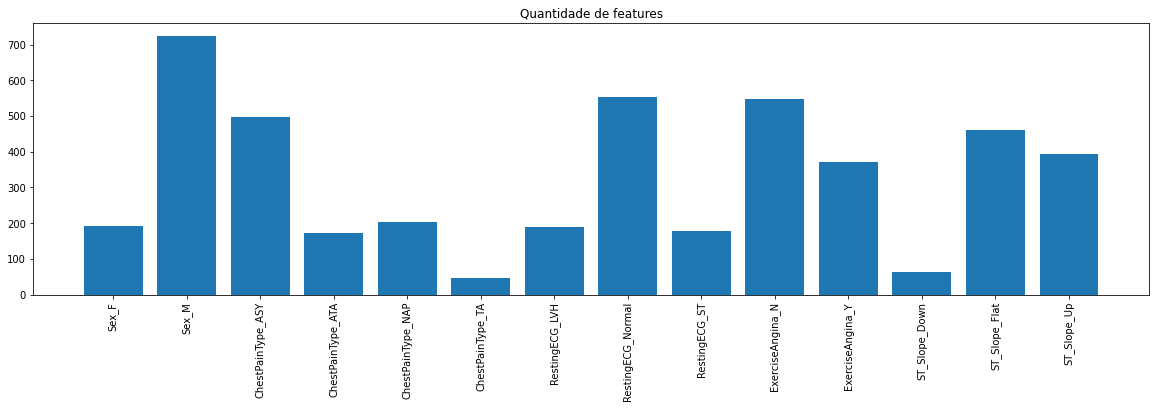

In [233]:
plt.figure(figsize=(20,5))
plt.bar(df_heart.iloc[:,7:].columns.array, df_heart.iloc[:,7:].sum().array)
plt.xticks(rotation='vertical')
plt.title('Quantidade de features')
plt.show()

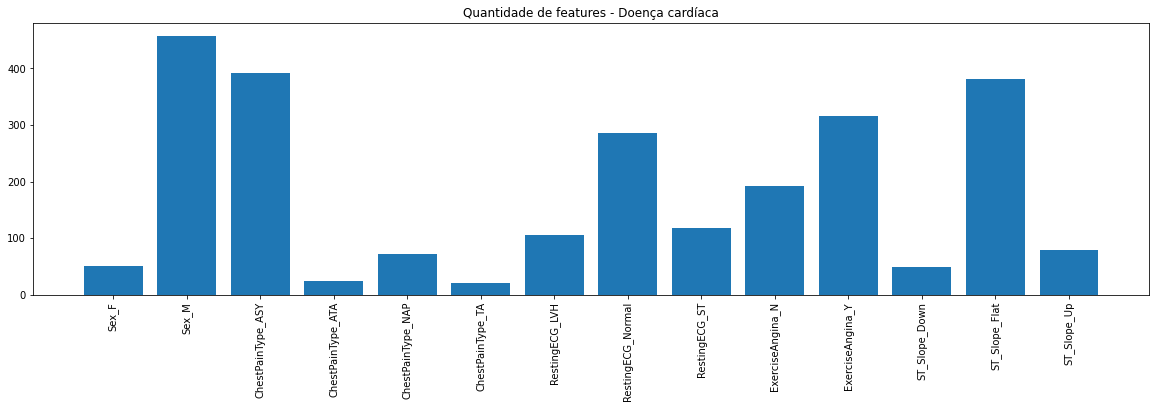

In [234]:
plt.figure(figsize=(20,5))
plt.bar(df_heart.iloc[:,7:].columns.array, df_heart[df_heart['HeartDisease']  == 1].iloc[:,7:].sum().array)
plt.xticks(rotation='vertical')
plt.title('Quantidade de features - Doença cardíaca')
plt.show()

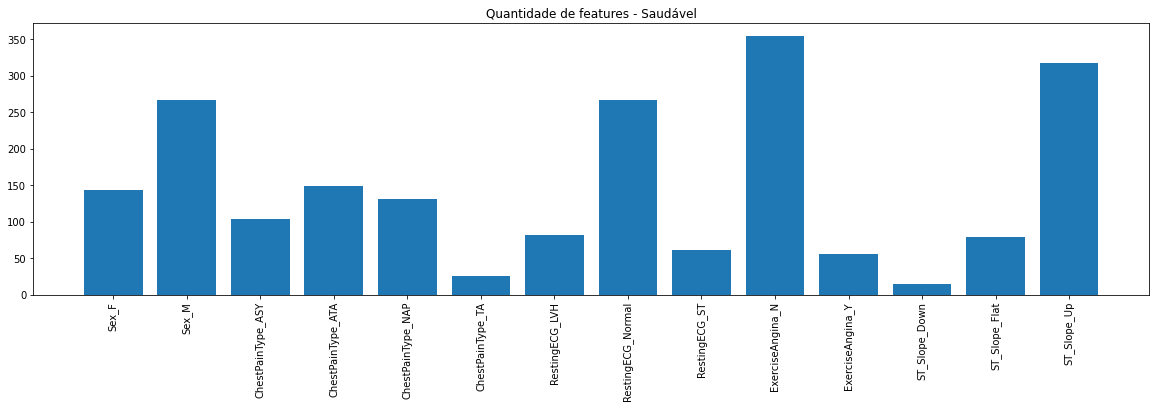

In [235]:
plt.figure(figsize=(20,5))
plt.bar(df_heart.iloc[:,7:].columns.array, df_heart[df_heart['HeartDisease']  == 0].iloc[:,7:].sum().array)
plt.xticks(rotation='vertical')
plt.title('Quantidade de features - Saudável')
plt.show()

In [236]:
df_heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377,0.210240,0.789760,0.540305,0.188453,0.221133,0.050109,0.204793,0.601307,0.193900,0.595861,0.404139,0.068627,0.501089,0.430283
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414,0.407701,0.407701,0.498645,0.391287,0.415236,0.218289,0.403770,0.489896,0.395567,0.490992,0.490992,0.252957,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [237]:
def separarDados(df,colunas):
  train_ratio = 0.60
  validation_ratio = 0.20
  test_ratio = 0.20

  x_treino, x_teste, y_treino, y_teste = train_test_split(df[colunas].loc[:, df[colunas].columns != 'HeartDisease'], df['HeartDisease'].values, test_size=1 - train_ratio)

  x_validacao, x_teste, y_validacao, y_teste = train_test_split(x_teste, y_teste, test_size=test_ratio/(test_ratio + validation_ratio))

  escala = StandardScaler().fit(x_treino)
  x_treino, x_validacao, x_teste = escala.transform(x_treino), escala.transform(x_validacao), escala.transform(x_teste)

  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [360]:
def executarModelo(modelo,nome,n,x_treino,y_treino,x_validacao,y_validacao):
  modelo.fit(x_treino,y_treino)

  filename = f'modelo{n}.sav'
  pickle.dump(modelo, open(filename, 'wb'))

  y_pred = modelo.predict(x_validacao)
    
  print(f'Acurácia do {nome} na validação é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
  print(f'Precisão do {nome} na validação é {round(precision_score(y_validacao, y_pred)*100,2)}%.')
  print(f'Recall do {nome} na validação é {round(recall_score(y_validacao, y_pred)*100,2)}%.')
  print()

In [239]:
def LDA_dados(x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste):
  lda = LinearDiscriminantAnalysis(n_components=1)

  return lda.fit_transform(x_treino,y_treino), lda.fit_transform(x_validacao,y_validacao), lda.fit_transform(x_teste,y_teste)

In [240]:
def PCA_dados(x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste):
  pca = PCA(n_components=15)

  return pca.fit_transform(x_treino,y_treino), pca.fit_transform(x_validacao,y_validacao), pca.fit_transform(x_teste,y_teste)

In [371]:
def graficoCluster(visualizacao,hue,n):
  sns.set(rc={'figure.figsize': (13, 13)})
  sns.scatterplot(x=visualizacao[:, 0],y=visualizacao[:, 1],hue=hue,palette=sns.color_palette('Paired',n))

In [389]:
def matrixConfusao(modelo,x_teste,y_teste,nome):
  y_pred = modelo.predict(x_teste)

  n_features = 2
  
  print(f'Acurácia do {nome} no teste é {round(accuracy_score(y_teste, y_pred)*100,2)}%.')
  print(f'Precisão do {nome} no teste é {round(precision_score(y_teste, y_pred)*100,2)}%.')
  print(f'Recall do {nome} no teste é {round(recall_score(y_teste, y_pred)*100,2)}%.')
  print()

  label = ["Saudável","Doença cardíaca"]

  cf_matrix = confusion_matrix(y_teste,y_pred)
  df_cm = pd.DataFrame(cf_matrix/cf_matrix.sum(axis=1).reshape(n_features,1), index=label, columns=label)

  list_texto = cf_matrix.tolist()
  for i in range(n_features):
    list_texto[i][i] = f"{list_texto[i][i]}/{(y_teste == i).sum()}"

  df_texto = pd.DataFrame(list_texto, index=label, columns=label).astype('string')

  sns.set(font_scale=2.0)
  fig, ax = plt.subplots(figsize=(18,15),dpi=65)
  fmt = lambda x,pos: '{:.0%}'.format(x)
  sns.heatmap(df_cm, annot=True, annot_kws={"size": 24,'va':'bottom'}, cmap='Blues', ax=ax, fmt='.2%',cbar_kws={'format': FuncFormatter(fmt)})
  sns.heatmap(df_cm, annot=df_texto, annot_kws={"size": 24,'va':'top'}, cmap='Blues',fmt='', ax=ax, cbar=False)

  plt.title(f"Matriz de Confusão do {nome}")
  plt.xlabel("Predito")
  plt.ylabel("Correto")

  plt.show()

In [259]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = separarDados(df_heart,df_heart.columns.array)
x_treino_lda,x_validacao_lda,x_teste_lda = LDA_dados(x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste)
x_treino_pca,x_validacao_pca,x_teste_pca = PCA_dados(x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste)

In [361]:
n = 1
nome = 'SGDClassifier'
modelo = SGDClassifier(random_state=False)

executarModelo(modelo,nome,n,x_treino,y_treino,x_validacao,y_validacao,)

executarModelo(modelo,f'{nome} - LDA',n,x_treino_lda,y_treino,x_validacao_lda,y_validacao)

Acurácia do SGDClassifier na validação é 82.61%.
Precisão do SGDClassifier na validação é 83.67%.
Recall do SGDClassifier na validação é 83.67%.

Acurácia do SGDClassifier - LDA na validação é 91.3%.
Precisão do SGDClassifier - LDA na validação é 91.84%.
Recall do SGDClassifier - LDA na validação é 91.84%.



In [362]:
n = 2
nome = 'SVC'
modelo = SVC()

executarModelo(modelo,nome,n,x_treino,y_treino,x_validacao,y_validacao)

executarModelo(modelo,f'{nome} - LDA',n,x_treino_lda,y_treino,x_validacao_lda,y_validacao)

Acurácia do SVC na validação é 87.5%.
Precisão do SVC na validação é 85.05%.
Recall do SVC na validação é 92.86%.

Acurácia do SVC - LDA na validação é 89.13%.
Precisão do SVC - LDA na validação é 87.5%.
Recall do SVC - LDA na validação é 92.86%.



In [363]:
n = 3
nome = 'RandomForestClassifier'
modelo = RandomForestClassifier()

executarModelo(modelo,nome,n,x_treino,y_treino,x_validacao,y_validacao)

executarModelo(modelo,f'{nome} - LDA',n,x_treino_lda,y_treino,x_validacao_lda,y_validacao)

Acurácia do RandomForestClassifier na validação é 88.59%.
Precisão do RandomForestClassifier na validação é 88.12%.
Recall do RandomForestClassifier na validação é 90.82%.

Acurácia do RandomForestClassifier - LDA na validação é 82.61%.
Precisão do RandomForestClassifier - LDA na validação é 83.67%.
Recall do RandomForestClassifier - LDA na validação é 83.67%.



In [364]:
n = 4
nome = 'VotingClassifier'

clf1 = SGDClassifier()
clf2 = SVC()
clf3 = RandomForestClassifier()

estimators = [('SGDClassifier', clf1), ('SVC', clf2), ('RandomForestClassifier', clf3)]

modelo = VotingClassifier(estimators=estimators, voting='hard')

executarModelo(modelo,nome,n,x_treino,y_treino,x_validacao,y_validacao)

executarModelo(modelo,f'{nome} - LDA',n,x_treino_lda,y_treino,x_validacao_lda,y_validacao)

Acurácia do VotingClassifier na validação é 89.13%.
Precisão do VotingClassifier na validação é 88.24%.
Recall do VotingClassifier na validação é 91.84%.

Acurácia do VotingClassifier - LDA na validação é 89.13%.
Precisão do VotingClassifier - LDA na validação é 89.0%.
Recall do VotingClassifier - LDA na validação é 90.82%.



In [365]:
n = 5
nome = 'LinearDiscriminantAnalysis'
modelo = LinearDiscriminantAnalysis()

executarModelo(modelo,nome,n,x_treino,y_treino,x_validacao,y_validacao)

executarModelo(modelo,f'{nome} - LDA',n,x_treino_lda,y_treino,x_validacao_lda,y_validacao)

Acurácia do LinearDiscriminantAnalysis na validação é 90.76%.
Precisão do LinearDiscriminantAnalysis na validação é 91.75%.
Recall do LinearDiscriminantAnalysis na validação é 90.82%.

Acurácia do LinearDiscriminantAnalysis - LDA na validação é 91.3%.
Precisão do LinearDiscriminantAnalysis - LDA na validação é 91.84%.
Recall do LinearDiscriminantAnalysis - LDA na validação é 91.84%.



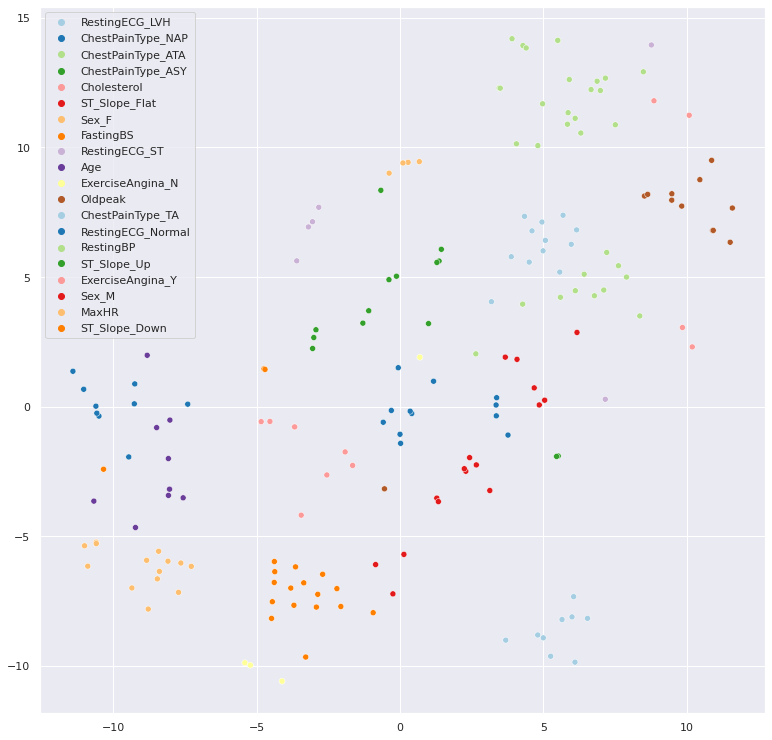

In [373]:
modelo = KMeans(n_clusters = 20, init='k-means++')
modelo.fit(x_validacao)

tsne = TSNE(n_components=2,n_iter=10000,learning_rate='auto',init='random')
visualizacao = tsne.fit_transform(x_validacao)

hue = [df_heart.columns.drop('HeartDisease')[modelo.labels_[i]] for i in range(modelo.labels_.shape[0])]

graficoCluster(visualizacao,hue,20)

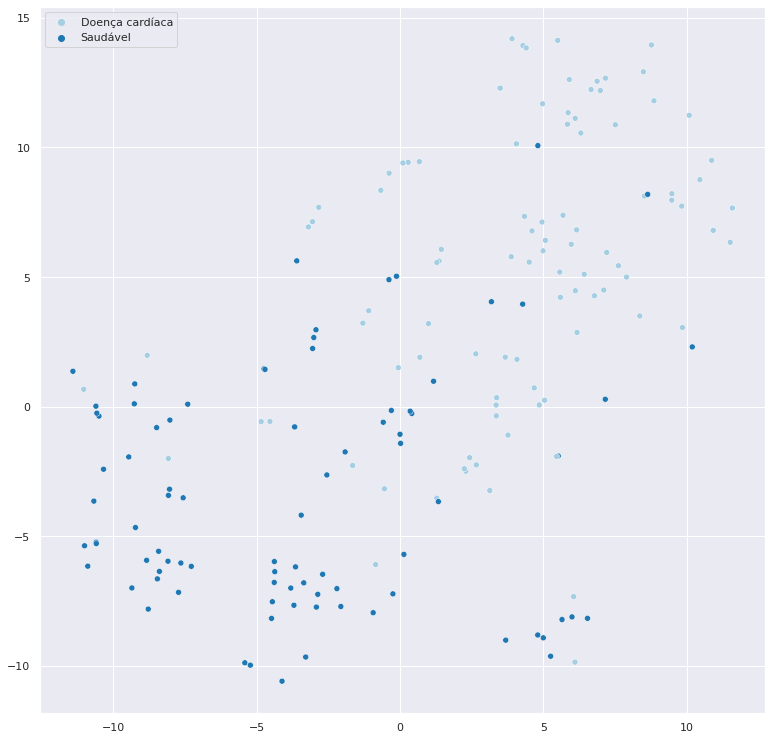

In [374]:
hue = ['Doença cardíaca' if y_validacao[i] == 1 else 'Saudável' for i in range(y_validacao.shape[0])]

graficoCluster(visualizacao,hue,2)

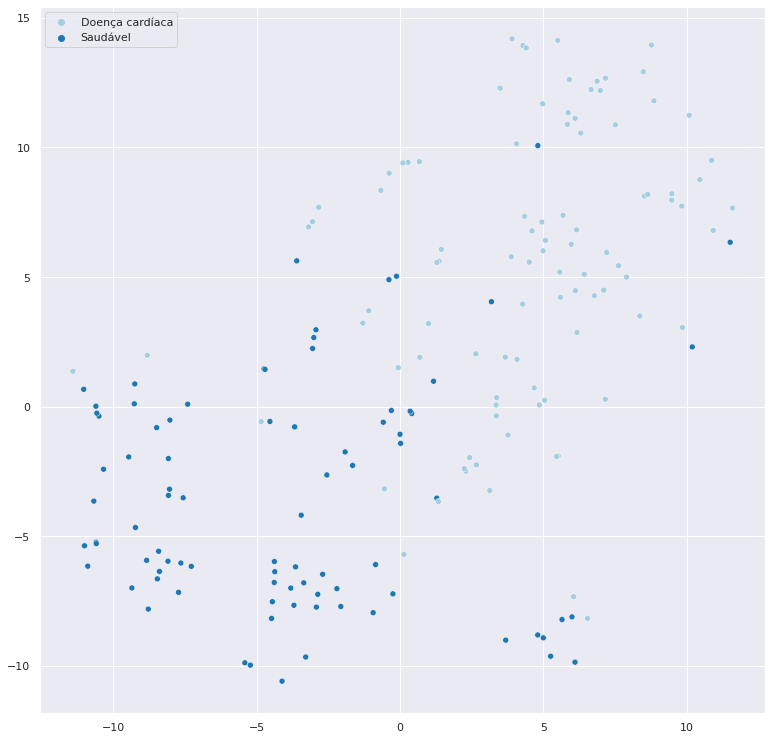

In [375]:
filename = 'modelo1.sav'
modelo = pickle.load(open(filename, 'rb'))

y_pred = modelo.predict(x_validacao_lda)

hue = ['Doença cardíaca' if y_pred[i] == 1 else 'Saudável' for i in range(y_pred.shape[0])]

graficoCluster(visualizacao,hue,2)

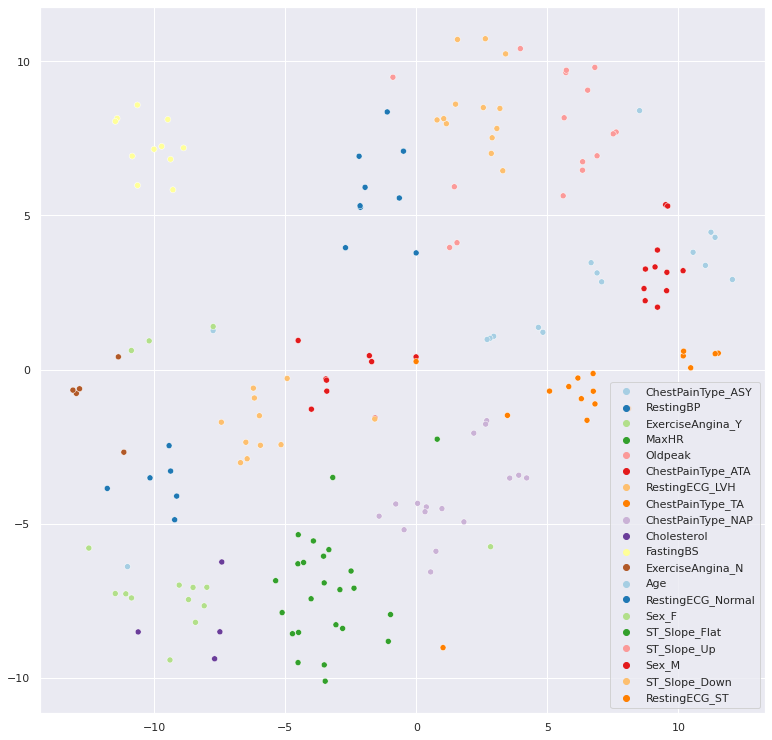

In [380]:
modelo = KMeans(n_clusters = 20, init='k-means++')
modelo.fit(x_teste)

tsne = TSNE(n_components=2,n_iter=10000,learning_rate='auto',init='random')
visualizacao = tsne.fit_transform(x_teste)

hue = [df_heart.columns.drop('HeartDisease')[modelo.labels_[i]] for i in range(modelo.labels_.shape[0])]

graficoCluster(visualizacao,hue,20)

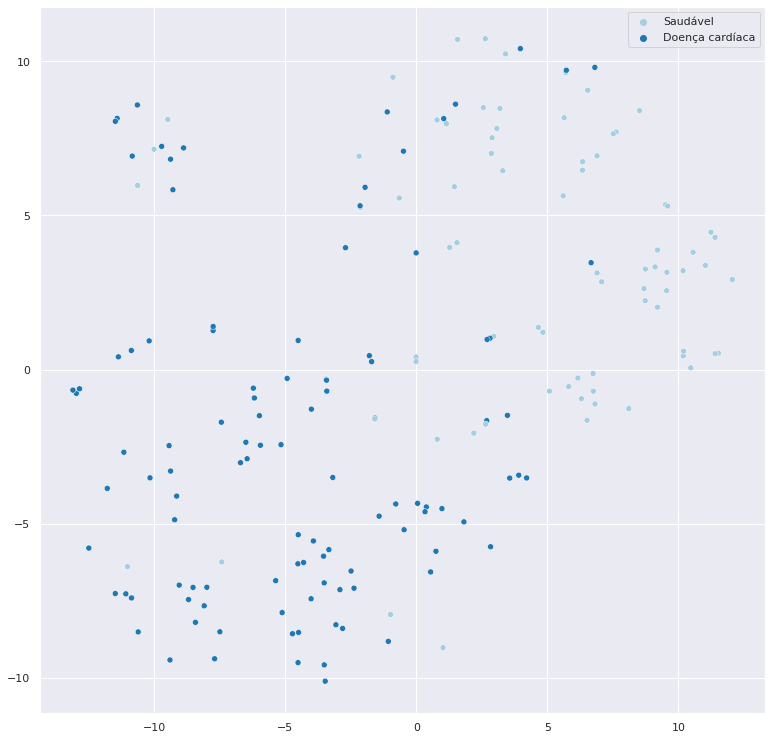

In [381]:
hue = ['Doença cardíaca' if y_teste[i] == 1 else 'Saudável' for i in range(y_teste.shape[0])]

graficoCluster(visualizacao,hue,2)

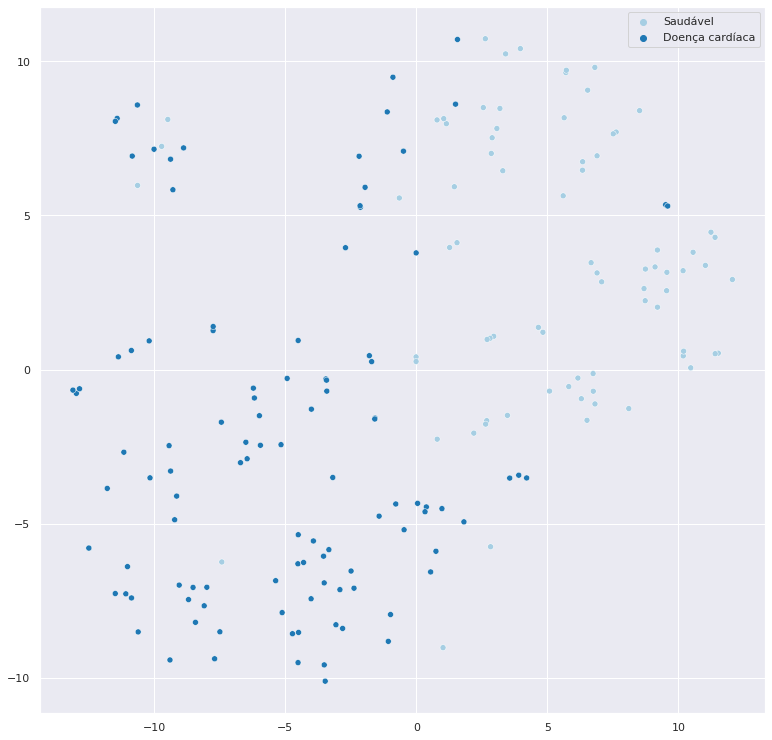

In [388]:
filename = 'modelo1.sav'
modelo = pickle.load(open(filename, 'rb'))

y_pred = modelo.predict(x_teste_lda)

hue = ['Doença cardíaca' if y_pred[i] == 1 else 'Saudável' for i in range(y_pred.shape[0])]

graficoCluster(visualizacao,hue,2)

Acurácia do SGDClassifier no teste é 88.04%.
Precisão do SGDClassifier no teste é 89.72%.
Recall do SGDClassifier no teste é 89.72%.



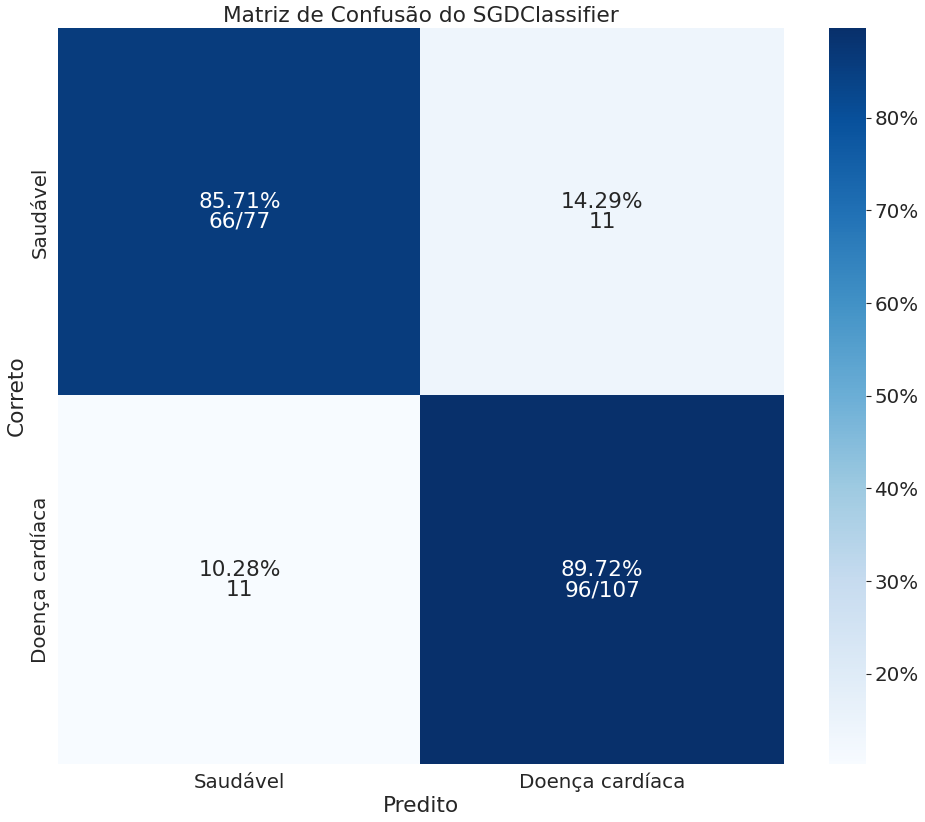

In [391]:
filename = 'modelo1.sav'
modelo = pickle.load(open(filename, 'rb'))

matrixConfusao(modelo,x_teste_lda,y_teste,"SGDClassifier")